# Regression

## Import Necessary Modules

Imports function libraries for our use in this demonstration, such as `random`, `torch`, and more:

-  **`random`**: Used for shuffling data randomly and selecting data randomly.
-  **`torch`**: The main machine learning (ML) and deep learning (DL) library that contains the necessary functions such as `nn` and `optim` to create neural network architectures and optimize them.

Other modules such as `matplotlib`, `res.plot_lib`, and `IPlot` will be used to display and represent the data graphically to make inferences through a visual representation.


In [4]:
import random
import torch
from torch import nn, optim
import math
from IPython import display
from res.plot_lib import plot_data, plot_model, set_default
from matplotlib import pyplot as plt

## Pre-requisites: Setting Up the Device

Before running the program, we configure display settings and select the computing hardware. The `set_default()` function in `NYUDLSP20/res/plot_lib.py` sets the figure size to **10x10 inches** for uniformity. To choose between **GPU** and **CPU**, we use `torch.device()`. If a CUDA-enabled GPU is available, it assigns "cuda:0"; otherwise, it defaults to CPU. 


In [5]:
set_default()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Create the Data

This section of the code generates data for us to manipulate. The function `random.seed()` is used to create deterministic random number generation for PyTorch applications, ensuring that the sequence of random numbers is reproducible. Changing the seed alters the sequence of random numbers, which can affect outcomes in simulations or model training.

The data is stored in the variables `X` and `Y`, both of which are 100 by 1 vectors:
-  `X` contains values linearly spaced from -1 to 1.
-  `Y` is calculated through the mathematical operation `X^3 + 0.3 * random()`, where each number in `X` is manipulated on an element-by-element basis.

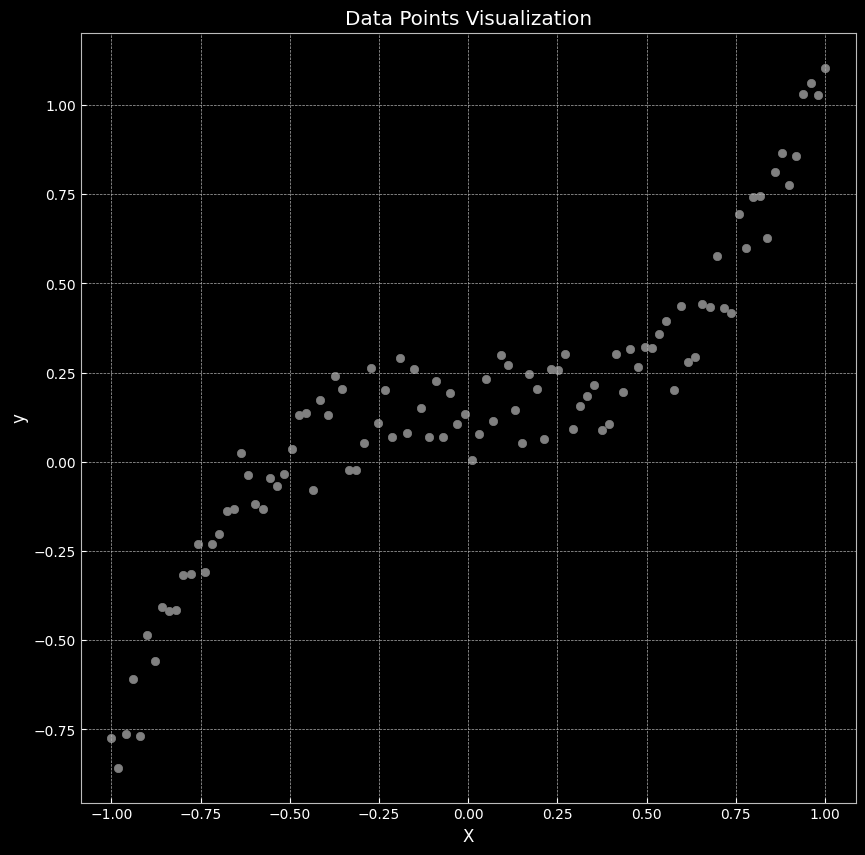

In [6]:
# Set a seed value to ensure reproducibility of random operations
seed = 1
random.seed(seed)           # Set seed for Python's built-in random module
torch.manual_seed(seed)     # Set seed for PyTorch to ensure reproducibility in tensor operations

# Generate X and y tensors/vectors
X = torch.unsqueeze(torch.linspace(-1, 1, 100), dim=1).to(device)   # 100 linearly spaced points between -1 and 1
y = X.pow(3) + 0.3 * torch.rand(X.size()).to(device)                # The random noise is scaled by 0.3 and added to X^3

# Plot the data points (X, y) using a scatter plot to visualize the relationship
plt.scatter(X.cpu().numpy(),
            y.cpu().numpy(),
            color='gray')
plt.title("Data Points Visualization")
plt.xlabel("X")
plt.ylabel("y")
plt.axis('equal')  # Ensuring equal scaling of axes
plt.show()


## **Linear Model Documentation**
This script implements a **linear regression model** using a simple **two-layer neural network**. The model learns a **linear approximation** of the given data points \(X\) and \(Y\) through **gradient-based optimization**.

In [7]:
# Define Model Parameters
N = 1000                # Total number of data samples
D = 1                   # Number of input features (dimensionality of X)
C = 1                   # Number of output values (dimensionality of y)
H = 100                 # Number of neurons in the hidden layer
learning_rate = 1e-3    # Learning rate for the optimizer (controls step size during gradient descent)
lambda_l2 = 1e-5        # Regularization factor for L2 weight decay (prevents overfitting)

# Define Model Architecture
model = nn.Sequential(
    nn.Linear(D, C),  # First layer: Maps input dimension (D) to hidden layer (H)
)
model.to(device)  # Move the model to GPU (if available) for faster computations

# Define Loss Function and Optimizer
criterion = torch.nn.MSELoss()  # Mean Squared Error (MSE) is used for regression tasks
optimizer = torch.optim.SGD(model.parameters(),         # Stochastic Gradient Descent (SGD) for optimization
                            lr=learning_rate,           # Learning rate that determines the update step size
                            weight_decay=lambda_l2)     # L2 regularization (prevents large weights)

# Training Loop
epochs = 1000                                   # Total number of training iterations
plot_epochs = list(range(0, epochs + 1, 100))   # Store model predictions every 100 epochs for visualization
predictions = {}                                # Dictionary to save predictions at specific epochs

for t in range(epochs + 1):
    # Forward pass: Compute model predictions
    y_pred = model(X)
    
    # Compute loss: Measures the difference between predicted and actual values
    loss = criterion(y_pred, y)
    
    # Zero out any previously stored gradients (to prevent accumulation)
    optimizer.zero_grad()
    
    # Backward pass: Compute gradients of loss w.r.t. model parameters
    loss.backward()
    
    # Update model parameters using computed gradients
    optimizer.step()
    
    # Save predictions at specific epochs for visualization
    if t in plot_epochs:
        predictions[t] = y_pred.detach().cpu().numpy()
    
    # Print progress update
    print(f"[EPOCH]: {t}, [LOSS]: {loss.item():.6f}")


/opt/anaconda3/envs/Learning_PyTorch/lib/python3.10/site-packages/onnxscript/converter.py:823: FutureWarning: 'onnxscript.values.Op.param_schemas' is deprecated in version 0.1 and will be removed in the future. Please use '.op_signature' instead.
  param_schemas = callee.param_schemas()
/opt/anaconda3/envs/Learning_PyTorch/lib/python3.10/site-packages/onnxscript/converter.py:823: FutureWarning: 'onnxscript.values.OnnxFunction.param_schemas' is deprecated in version 0.1 and will be removed in the future. Please use '.op_signature' instead.
  param_schemas = callee.param_schemas()


[EPOCH]: 0, [LOSS]: 0.176448
[EPOCH]: 1, [LOSS]: 0.175949
[EPOCH]: 2, [LOSS]: 0.175453
[EPOCH]: 3, [LOSS]: 0.174958
[EPOCH]: 4, [LOSS]: 0.174465
[EPOCH]: 5, [LOSS]: 0.173975
[EPOCH]: 6, [LOSS]: 0.173485
[EPOCH]: 7, [LOSS]: 0.172998
[EPOCH]: 8, [LOSS]: 0.172513
[EPOCH]: 9, [LOSS]: 0.172029
[EPOCH]: 10, [LOSS]: 0.171547
[EPOCH]: 11, [LOSS]: 0.171067
[EPOCH]: 12, [LOSS]: 0.170589
[EPOCH]: 13, [LOSS]: 0.170113
[EPOCH]: 14, [LOSS]: 0.169638
[EPOCH]: 15, [LOSS]: 0.169165
[EPOCH]: 16, [LOSS]: 0.168694
[EPOCH]: 17, [LOSS]: 0.168225
[EPOCH]: 18, [LOSS]: 0.167758
[EPOCH]: 19, [LOSS]: 0.167292
[EPOCH]: 20, [LOSS]: 0.166828
[EPOCH]: 21, [LOSS]: 0.166365
[EPOCH]: 22, [LOSS]: 0.165905
[EPOCH]: 23, [LOSS]: 0.165446
[EPOCH]: 24, [LOSS]: 0.164989
[EPOCH]: 25, [LOSS]: 0.164533
[EPOCH]: 26, [LOSS]: 0.164080
[EPOCH]: 27, [LOSS]: 0.163628
[EPOCH]: 28, [LOSS]: 0.163177
[EPOCH]: 29, [LOSS]: 0.162729
[EPOCH]: 30, [LOSS]: 0.162282
[EPOCH]: 31, [LOSS]: 0.161837
[EPOCH]: 32, [LOSS]: 0.161393
[EPOCH]: 33, [LOSS]:

In [9]:
# Define Model Parameters
N = 1000                # Total number of data samples
D = 1                   # Number of input features (dimensionality of X)
C = 1                   # Number of output values (dimensionality of y)
H = 100                 # Number of neurons in the hidden layer
learning_rate = 1e-3    # Learning rate for the optimizer (controls step size during gradient descent)
lambda_l2 = 1e-5        # Regularization factor for L2 weight decay (prevents overfitting)

# Define Model Architecture
model = nn.Sequential(
    nn.Linear(D, H),  # First layer: Maps input dimension (D) to hidden layer (H)
    nn.Linear(H, C)   # Second layer: Maps hidden layer (H) to output (C)
)
model.to(device)  # Move the model to GPU (if available) for faster computations

# Define Loss Function and Optimizer
criterion = torch.nn.MSELoss()  # Mean Squared Error (MSE) is used for regression tasks
optimizer = torch.optim.SGD(model.parameters(),         # Stochastic Gradient Descent (SGD) for optimization
                            lr=learning_rate,           # Learning rate that determines the update step size
                            weight_decay=lambda_l2)     # L2 regularization (prevents large weights)

# Training Loop
epochs = 1000                                   # Total number of training iterations
plot_epochs = list(range(0, epochs + 1, 100))   # Store model predictions every 100 epochs for visualization
predictions = {}                                # Dictionary to save predictions at specific epochs

for t in range(epochs + 1):
    # Forward pass: Compute model predictions
    y_pred = model(X)
    
    # Compute loss: Measures the difference between predicted and actual values
    loss = criterion(y_pred, y)
    
    # Zero out any previously stored gradients (to prevent accumulation)
    optimizer.zero_grad()
    
    # Backward pass: Compute gradients of loss w.r.t. model parameters
    loss.backward()
    
    # Update model parameters using computed gradients
    optimizer.step()
    
    # Save predictions at specific epochs for visualization
    if t in plot_epochs:
        predictions[t] = y_pred.detach().cpu().numpy()
    
    # Print progress update
    print(f"[EPOCH]: {t}, [LOSS]: {loss.item():.6f}")


[EPOCH]: 0, [LOSS]: 0.323910
[EPOCH]: 1, [LOSS]: 0.305337
[EPOCH]: 2, [LOSS]: 0.288248
[EPOCH]: 3, [LOSS]: 0.272491
[EPOCH]: 4, [LOSS]: 0.257934
[EPOCH]: 5, [LOSS]: 0.244457
[EPOCH]: 6, [LOSS]: 0.231959
[EPOCH]: 7, [LOSS]: 0.220347
[EPOCH]: 8, [LOSS]: 0.209540
[EPOCH]: 9, [LOSS]: 0.199467
[EPOCH]: 10, [LOSS]: 0.190062
[EPOCH]: 11, [LOSS]: 0.181270
[EPOCH]: 12, [LOSS]: 0.173038
[EPOCH]: 13, [LOSS]: 0.165323
[EPOCH]: 14, [LOSS]: 0.158083
[EPOCH]: 15, [LOSS]: 0.151281
[EPOCH]: 16, [LOSS]: 0.144884
[EPOCH]: 17, [LOSS]: 0.138863
[EPOCH]: 18, [LOSS]: 0.133190
[EPOCH]: 19, [LOSS]: 0.127841
[EPOCH]: 20, [LOSS]: 0.122794
[EPOCH]: 21, [LOSS]: 0.118028
[EPOCH]: 22, [LOSS]: 0.113526
[EPOCH]: 23, [LOSS]: 0.109269
[EPOCH]: 24, [LOSS]: 0.105242
[EPOCH]: 25, [LOSS]: 0.101432
[EPOCH]: 26, [LOSS]: 0.097824
[EPOCH]: 27, [LOSS]: 0.094407
[EPOCH]: 28, [LOSS]: 0.091169
[EPOCH]: 29, [LOSS]: 0.088100
[EPOCH]: 30, [LOSS]: 0.085190
[EPOCH]: 31, [LOSS]: 0.082430
[EPOCH]: 32, [LOSS]: 0.079812
[EPOCH]: 33, [LOSS]:

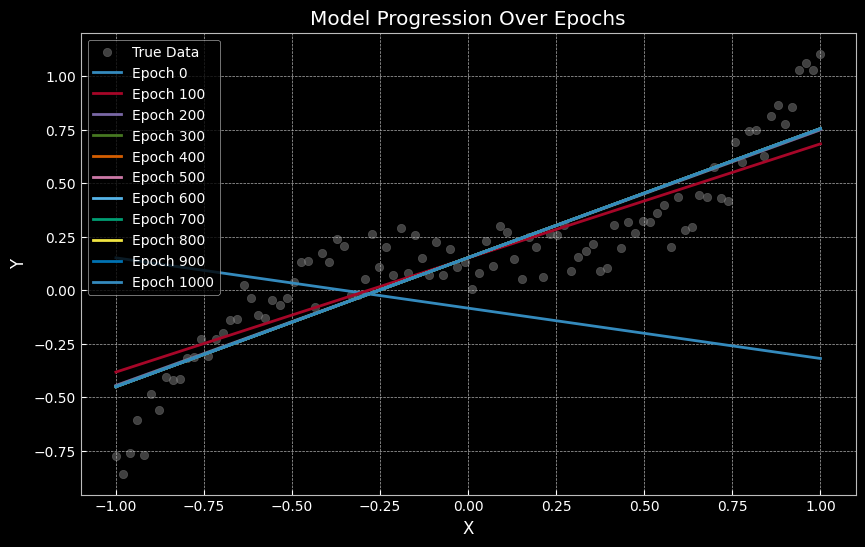

In [10]:
# Plot all stored predictions
plt.figure(figsize=(10, 6))
plt.scatter(X.cpu().numpy(), 
            y.cpu().numpy(), 
            color='gray', 
            alpha=0.5, 
            label="True Data")

for epoch, pred in predictions.items():
    plt.plot(X.cpu().numpy(), pred, label=f"Epoch {epoch}")

plt.title("Model Progression Over Epochs")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

In [ ]:
# Plot trained model
print(model)
plt.scatter(X.data.cpu().numpy(), y.data.cpu().numpy())
plt.plot(X.data.cpu().numpy(), y_pred.data.cpu().numpy(), 'r-', lw=5)
plt.axis('equal');


## Two-layered network

In [19]:
learning_rate = 1e-3
lambda_l2 = 1e-5

In [ ]:
# Number of networks
n_networks = 10
models = list()
y_pretrain = list()

# nn package also has different loss functions.
# we use MSE for a regression task
criterion = torch.nn.MSELoss()

for mod in range(n_networks):
    # nn package to create our linear model
    # each Linear module has a weight and bias
    model = nn.Sequential(
        nn.Linear(D, H),
        nn.ReLU() if mod < n_networks // 2 else nn.Tanh(),
        nn.Linear(H, C)
    )
    model.to(device)
    
    # Append models
    models.append(model)

    # we use the optim package to apply
    # ADAM for our parameter updates
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=lambda_l2) # built-in L2

    # e = 1.  # plotting purpose

    # Training
    for t in range(1000):

        # Feed forward to get the logits
        y_pred = model(X)
        
        # Append pre-train output
        if t == 0:
            y_pretrain.append(y_pred.detach())

        # Compute the loss and accuracy
        loss = criterion(y_pred, y)
        print(f"[MODEL]: {mod + 1}, [EPOCH]: {t}, [LOSS]: {loss.item():.6f}")
        display.clear_output(wait=True)

        # zero the gradients before running
        # the backward pass.
        optimizer.zero_grad()

        # Backward pass to compute the gradient
        # of loss w.r.t our learnable params. 
        loss.backward()

        # Update params
        optimizer.step()

In [ ]:
print(models[0], models[-1])
from torch.utils.tensorboard import SummaryWriter

# Set up TensorBoard
writer = SummaryWriter('runs/experiment_1')
# Choose a model to visualize
model = models[0]

# You must pass a sample input tensor appropriate for your model
sample_input = torch.randn(1, 1).to(device)  # Adjust the shape according to your model's input

# Add the model graph; this requires a sample input through which the graph will be traced
writer.add_graph(model, sample_input)
writer.close()



## Predictions: Before Training

In [ ]:
for y_pretrain_idx in y_pretrain:
    # New X that ranges from -5 to 5 instead of -1 to 1
    X_new = torch.unsqueeze(torch.linspace(-2, 2, 100), dim=1)
        
    plt.plot(X_new.numpy(), y_pretrain_idx.cpu().numpy(), 'r-', lw=1)

plt.scatter(X.cpu().numpy(), y.cpu().numpy(), label='data')
plt.axis('square')
plt.axis((-1.1, 1.1, -1.1, 1.1));
y_combo = torch.stack(y_pretrain)
plt.plot(X_new.numpy(), y_combo.var(dim=0).cpu().numpy(), 'g', label='variance');
plt.legend()

## Predictions: After Training

In [ ]:
y_pred = list()
relu_models = models[:n_networks // 2]
tanh_models = models[n_networks // 2:]
plt.figure(figsize=(20, 10))

def dense_prediction(models, non_linearity, zoom):
    plt.subplot(1, 2, 1 if non_linearity == 'ReLU' else 2)
    for model in models:
        # New X that ranges from -5 to 5 instead of -1 to 1
        X_new = torch.unsqueeze(torch.linspace(-4, 4, 1001), dim=1).to(device)

        # Getting predictions from input
        with torch.no_grad():
            y_pred.append(model(X_new))

        plt.plot(X_new.cpu().numpy(), y_pred[-1].cpu().numpy(), 'r-', lw=1)
    plt.scatter(X.cpu().numpy(), y.cpu().numpy(), label='data')
    plt.axis('square')
    plt.axis(torch.tensor((-1.1, 1.1, -1.1, 1.1)) * zoom);
    y_combo = torch.stack(y_pred)
    plt.plot(X_new.cpu().numpy(), 10 * y_combo.var(dim=0).cpu().sqrt().numpy(), 'y', label='10 × std')
    plt.plot(X_new.cpu().numpy(), 10 * y_combo.var(dim=0).cpu().numpy(), 'g', label='30 × variance')
    plt.legend()
    plt.title(non_linearity + ' models')

z = 1  # try 1 or 4
dense_prediction(relu_models, 'ReLU', zoom=z)
dense_prediction(tanh_models, 'Tanh', zoom=z)